In [3]:
import os
import sys
parent_dir = os.path.abspath('..')
sys.path.append(parent_dir) #set root to path so src visible

# Import des librairies
!pip install catboost xgboost lightgbm catboost scikit-learn matplotlib  pandas wordcloud textblob transformers torch vaderSentiment-fr
import numpy as np
import matplotlib.pyplot as plt 

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor

In [4]:
df_portefeuille1 = data_loading("training")[0]
df_portefeuille2 = data_loading("validation")[0]

df_portefeuille = pd.concat([df_portefeuille1, df_portefeuille2], ignore_index=True)

In [5]:
set(df_portefeuille1.columns) == set(df_portefeuille2.columns)

True

In [6]:
df_portefeuille.shape

(171025, 47)

In [7]:
df = df_portefeuille
# Liste des colonnes cibles
colonnes_nps = [
    'client_nps_date_reponse_n', 
    'client_nps_note_reco_n', 
    'client_nps_verbatim_n', 
    'client_nps_date_reponse_n_moins1', 
    'client_nps_note_reco_n_moins1', 
    'client_nps_verbatim_n_moins1',
    'target_resiliation_6mois'

]

# Extraction dans un nouveau DataFrame
df_nps = df[colonnes_nps]

# Afficher les premières lignes pour vérifier
print(df_nps.head())

  client_nps_date_reponse_n  client_nps_note_reco_n client_nps_verbatim_n  \
0                       NaN                     NaN                   NaN   
1                       NaN                     NaN                   NaN   
2                       NaN                     NaN                   NaN   
3                       NaN                     NaN                   NaN   
4                       NaN                     NaN                   NaN   

  client_nps_date_reponse_n_moins1  client_nps_note_reco_n_moins1  \
0                              NaN                            NaN   
1                              NaN                            NaN   
2                              NaN                            NaN   
3                              NaN                            NaN   
4                              NaN                            NaN   

  client_nps_verbatim_n_moins1  target_resiliation_6mois  
0                          NaN                         0  
1   

In [8]:
df_nps.isna().sum()

client_nps_date_reponse_n           160475
client_nps_note_reco_n              160475
client_nps_verbatim_n               162741
client_nps_date_reponse_n_moins1    163819
client_nps_note_reco_n_moins1       163819
client_nps_verbatim_n_moins1        165329
target_resiliation_6mois                 0
dtype: int64

/opt/python/lib/python3.13/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')
/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:httpx:HTTP Request: HEAD https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nlptown/bert-base-multilingual-uncased-sentiment/8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15227.22it/s]
INFO:httpx:HTTP Request: GET https://huggingface.

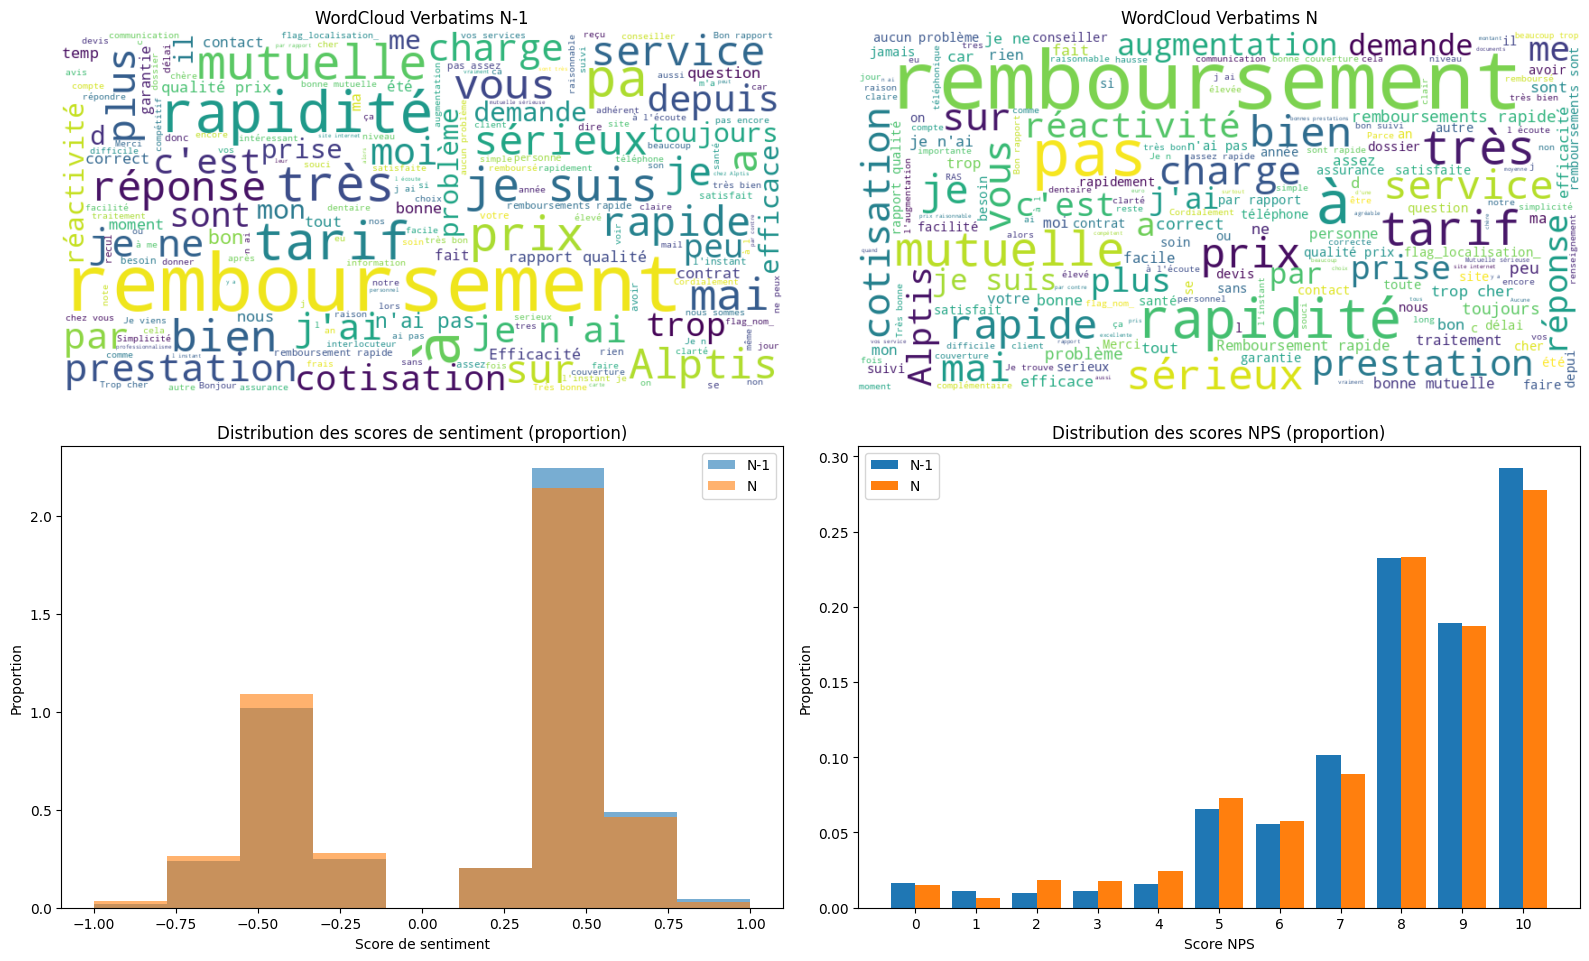

Note moyenne N-1 : 7.98
Note moyenne N   : 7.85

Répartition sentiments N-1 :
sentiment_label_n1
Positif    1085
Neutre        0
Négatif     554
Name: count, dtype: int64

Répartition sentiments N :
sentiment_label_n
Positif    1032
Neutre        0
Négatif     607
Name: count, dtype: int64


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline



df_nps = df.dropna(subset=['client_nps_verbatim_n', 'client_nps_verbatim_n_moins1']).copy()

sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

def sentiment_transformer(text):
    result = sentiment_model(str(text))[0]
    return result["score"] if result["label"] in ["4 stars", "5 stars"] else -result["score"]


def sentiment_label(score):
    if score > 0.1:
        return "Positif"
    elif score < -0.1:
        return "Négatif"
    else:
        return "Neutre"

df_nps["sentiment_score_n"] = df_nps["client_nps_verbatim_n"].apply(sentiment_transformer)
df_nps["sentiment_score_n1"] = df_nps["client_nps_verbatim_n_moins1"].apply(sentiment_transformer)

df_nps["sentiment_label_n"] = df_nps["sentiment_score_n"].apply(sentiment_label)
df_nps["sentiment_label_n1"] = df_nps["sentiment_score_n1"].apply(sentiment_label)

texte_n = " ".join(df_nps["client_nps_verbatim_n"].astype(str))
texte_n1 = " ".join(df_nps["client_nps_verbatim_n_moins1"].astype(str))

stop_words = set([
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'dans',
    'pour', 'que', 'qui', 'au', 'aux', 'avec', 'ce', 'cette', 'ces', 'est'
])

wordcloud_n = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n)

wordcloud_n1 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n1)

mean_n = df_nps["client_nps_note_reco_n"].mean()
mean_n1 = df_nps["client_nps_note_reco_n_moins1"].mean()

sent_n = df_nps["sentiment_label_n"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)
sent_n1 = df_nps["sentiment_label_n1"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(wordcloud_n1, interpolation="bilinear")
axes[0, 0].axis("off")
axes[0, 0].set_title("WordCloud Verbatims N-1")

axes[0, 1].imshow(wordcloud_n, interpolation="bilinear")
axes[0, 1].axis("off")
axes[0, 1].set_title("WordCloud Verbatims N")

bins = np.linspace(-1, 1, 10)

axes[1, 0].hist(
    df_nps["sentiment_score_n1"],
    bins=bins,
    alpha=0.6,
    label="N-1",
    density=True
)

axes[1, 0].hist(
    df_nps["sentiment_score_n"],
    bins=bins,
    alpha=0.6,
    label="N",
    density=True
)

axes[1, 0].set_title("Distribution des scores de sentiment (proportion)")
axes[1, 0].set_xlabel("Score de sentiment")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend()

bins = np.arange(0, 12) - 0.5

counts_n1, _ = np.histogram(df_nps["client_nps_note_reco_n_moins1"], bins=bins)
counts_n, _ = np.histogram(df_nps["client_nps_note_reco_n"], bins=bins)

prop_n1 = counts_n1 / counts_n1.sum()
prop_n = counts_n / counts_n.sum()

x = np.arange(0, 11)
axes[1, 1].bar(x - 0.2, prop_n1, width=0.4, label="N-1")
axes[1, 1].bar(x + 0.2, prop_n, width=0.4, label="N")
axes[1, 1].set_xticks(x)
axes[1, 1].set_title("Distribution des scores NPS (proportion)")
axes[1, 1].set_xlabel("Score NPS")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

print(f"Note moyenne N-1 : {mean_n1:.2f}")
print(f"Note moyenne N   : {mean_n:.2f}")

print("\nRépartition sentiments N-1 :")
print(sent_n1)

print("\nRépartition sentiments N :")
print(sent_n)

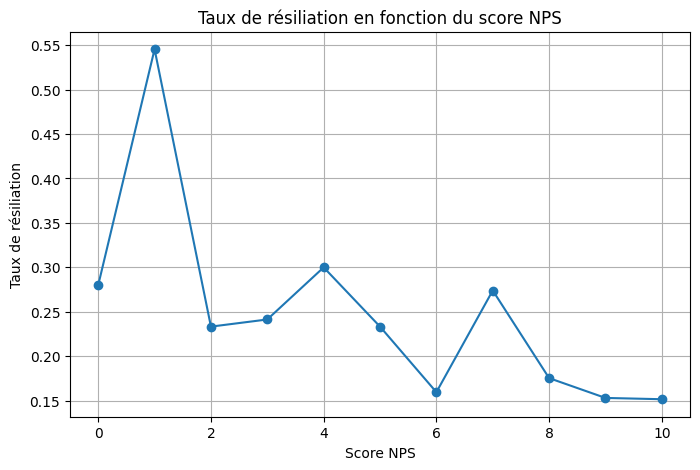

In [10]:
resiliation_by_nps = df_nps.groupby("client_nps_note_reco_n")["target_resiliation_6mois"].mean()

plt.figure(figsize=(8,5))
resiliation_by_nps.plot(marker="o")

plt.title("Taux de résiliation en fonction du score NPS")
plt.xlabel("Score NPS")
plt.ylabel("Taux de résiliation")
plt.grid()

plt.show()

Nombre de clients mentionnant la résiliation : 14

Résumé :
                           churn_rate  count
flag_resiliation_verbatim                   
False                        0.185231   1625
True                         0.285714     14


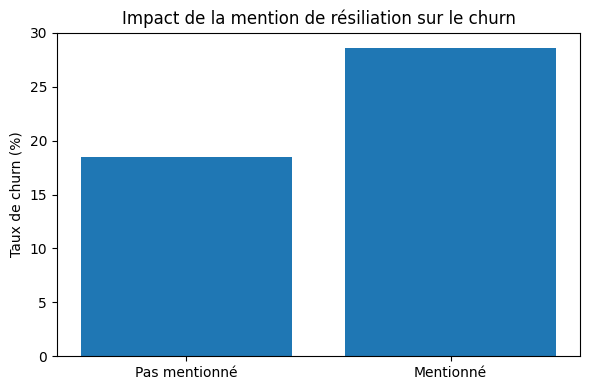

In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# 1. Flag résiliation
keywords_resiliation = [
    "résiliation","resiliation","résilier","resilier","résilié","resilie",
    "quitter","partir","changer","annuler","stop","mettre fin","je pars"
    "je vais partir","je pense partir","changer d'assurance","aller ailleurs"
]

pattern = "|".join(keywords_resiliation)

df_nps["flag_resiliation_verbatim"] = (
    df_nps["client_nps_verbatim_n"]
    .str.lower()
    .str.contains(pattern, regex=True, na=False)
)

# 2. Nombre de clients
n_clients = df_nps["flag_resiliation_verbatim"].sum()
print(f"Nombre de clients mentionnant la résiliation : {n_clients}")

# 3-4. Impact sur le churn (table propre)
summary = df_nps.groupby("flag_resiliation_verbatim").agg(
    churn_rate=("target_resiliation_6mois", "mean"),
    count=("target_resiliation_6mois", "size")
)

print("\nRésumé :")
print(summary)

# 5. Graphique
plot_df = summary.copy()
plot_df["churn_rate"] = plot_df["churn_rate"] * 100
plot_df["label"] = ["Pas mentionné", "Mentionné"]

plt.figure(figsize=(6,4))
plt.bar(plot_df["label"], plot_df["churn_rate"])
plt.title("Impact de la mention de résiliation sur le churn")
plt.ylabel("Taux de churn (%)")
plt.tight_layout()
plt.show()

In [12]:
# Liste de mots-clés liés au prix/tarif
mots_cles_prix = ['prix', 'tarif', 'cher', 'cotisation', 'augmentation', 'coût', 'cout']

# Création d'un flag (0 ou 1) pour les clients mentionnant le prix
pattern = '|'.join(mots_cles_prix)
df_nps['mention_prix'] = df_nps['client_nps_verbatim_n'].str.contains(pattern, case=False, na=False)

# On affine : on ne veut que ceux qui en parlent NÉGATIVEMENT (Sentiment < 0)
df_prix_negatif = df_nps[(df_nps['mention_prix'] == True) & (df_nps['sentiment_score_n'] < 0)]

In [13]:
target = 'target_resiliation_6mois'

taux_churn_prix = df_prix_negatif[target].mean() * 100
taux_churn_global = df_nps[target].mean() * 100

print(f"Nombre de clients mécontents du prix : {len(df_prix_negatif)}")
print(f"Taux de churn (Segment Prix) : {taux_churn_prix:.2f}%")
print(f"Taux de churn (Moyenne Globale) : {taux_churn_global:.2f}%")

# Calcul de l' "Over-risk" (Sur-risque)
sur_risque = taux_churn_prix / taux_churn_global
print(f"Ces clients sont {sur_risque:.1f} fois plus susceptibles de partir.")

Nombre de clients mécontents du prix : 241
Taux de churn (Segment Prix) : 24.07%
Taux de churn (Moyenne Globale) : 18.61%
Ces clients sont 1.3 fois plus susceptibles de partir.


/tmp/ipykernel_3289022/4151564389.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Groupe', y='Taux de Churn (%)', data=data_plot, palette=['grey', 'red'])


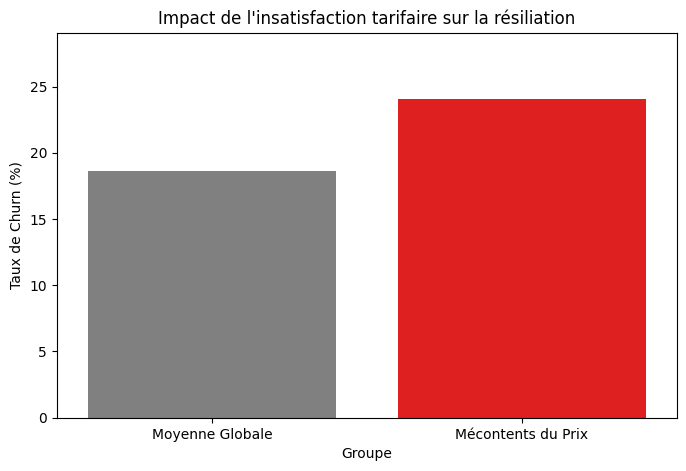

In [14]:
import seaborn as sns

data_plot = pd.DataFrame({
    'Groupe': ['Moyenne Globale', 'Mécontents du Prix'],
    'Taux de Churn (%)': [taux_churn_global, taux_churn_prix]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Groupe', y='Taux de Churn (%)', data=data_plot, palette=['grey', 'red'])
plt.title('Impact de l\'insatisfaction tarifaire sur la résiliation')
plt.ylim(0, max(taux_churn_prix, taux_churn_global) + 5)
plt.show()

In [15]:
# 1. Définition des segments NPS
def segment_nps(note):
    if note <= 6:
        return 'Détracteur'
    elif note <= 8:
        return 'Passif'
    else:
        return 'Promoteur'

df_nps['categorie_nps'] = df_nps['client_nps_note_reco_n'].apply(segment_nps)

# 2. Calcul du taux de churn par segment
target = 'target_resiliation_6mois'
stats_nps = df_nps.groupby('categorie_nps')[target].mean() * 100

# 3. Affichage des résultats
print("--- Taux de Churn par Segment NPS ---")
print(stats_nps.sort_values(ascending=False))

--- Taux de Churn par Segment NPS ---
categorie_nps
Détracteur    23.495702
Passif        20.265152
Promoteur     15.223097
Name: target_resiliation_6mois, dtype: float64


/tmp/ipykernel_3289022/1056201347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_nps.index, y=stats_nps.values, palette='coolwarm')


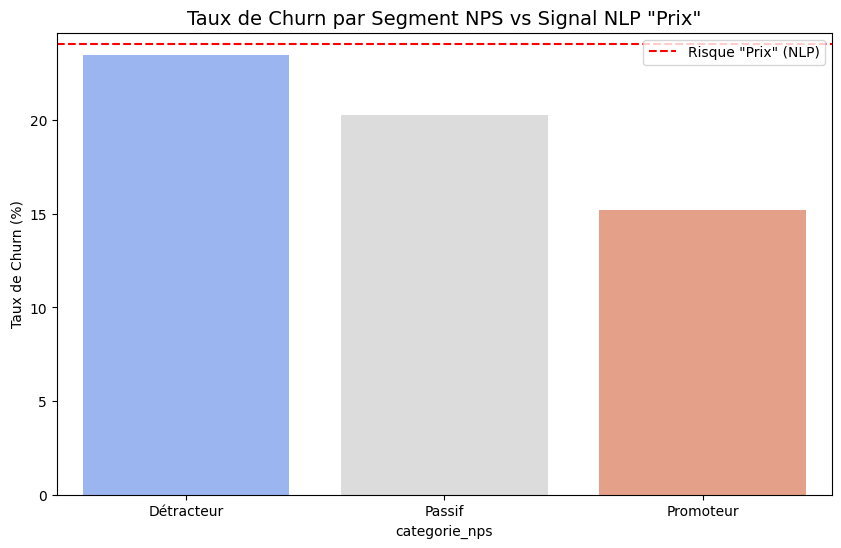

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=stats_nps.index, y=stats_nps.values, palette='coolwarm')
plt.axhline(taux_churn_prix, color='red', linestyle='--', label='Risque "Prix" (NLP)')
plt.title('Taux de Churn par Segment NPS vs Signal NLP "Prix"', fontsize=14)
plt.ylabel('Taux de Churn (%)')
plt.legend()
plt.show()

In [17]:
df_prix_negatif = df_nps[(df_nps['mention_prix'] == True) & (df_nps['sentiment_score_n'] < 0)]
# Calcul du taux de churn par catégorie NPS pour le segment prix négatif
resultat_churn_prix = df_prix_negatif.groupby('categorie_nps')['target_resiliation_6mois'].mean() * 100

# Affichage direct
print(resultat_churn_prix.sort_values(ascending=False))

categorie_nps
Détracteur    26.114650
Promoteur     25.000000
Passif        17.857143
Name: target_resiliation_6mois, dtype: float64


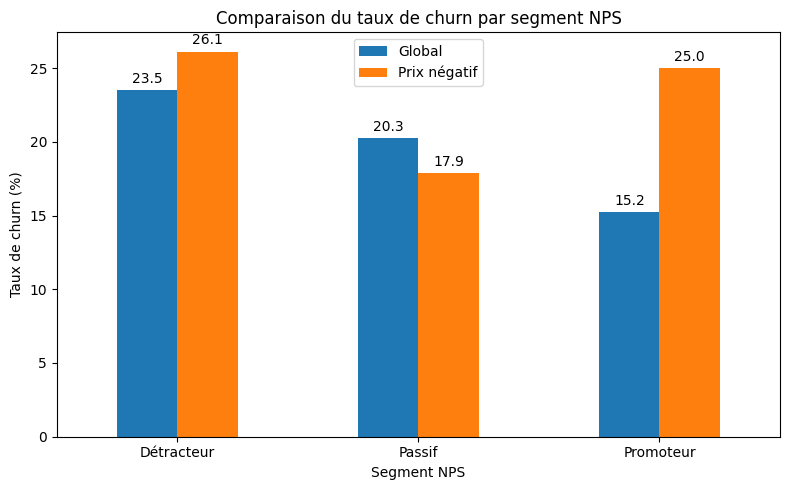

In [18]:
df_compare = pd.DataFrame({
    'Global': stats_nps,
    'Prix négatif': resultat_churn_prix
})


ax = df_compare.plot(kind='bar', figsize=(8,5))

plt.title("Comparaison du taux de churn par segment NPS")
plt.ylabel("Taux de churn (%)")
plt.xlabel("Segment NPS")
plt.xticks(rotation=0)

# 🔥 Ajout des labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.legend()
plt.tight_layout()
plt.show()

In [19]:
def compute_nps_detail(scores: pd.Series):
    scores = scores.dropna()

    pct_promoteurs = ((scores >= 9) & (scores <= 10)).mean() * 100
    pct_passifs = ((scores >= 7) & (scores <= 8)).mean() * 100
    pct_detracteurs = ((scores >= 0) & (scores <= 6)).mean() * 100

    nps = pct_promoteurs - pct_detracteurs

    return {
        "NPS": nps,
        "% promoteurs": pct_promoteurs,
        "% passifs": pct_passifs,
        "% détracteurs": pct_detracteurs
    }


In [20]:
scores = df["client_nps_note_reco_n"].dropna()
compute_nps_detail(scores)

{'NPS': np.float64(20.151658767772513),
 '% promoteurs': np.float64(43.32701421800948),
 '% passifs': np.float64(33.497630331753555),
 '% détracteurs': np.float64(23.175355450236967)}

In [21]:
scores = df["client_nps_note_reco_n_moins1"].dropna()
compute_nps_detail(scores)

{'NPS': np.float64(18.887038578961974),
 '% promoteurs': np.float64(42.17318900915903),
 '% passifs': np.float64(34.54066056064391),
 '% détracteurs': np.float64(23.286150430197058)}

In [22]:
scores = df["client_nps_note_reco_n_moins1"].dropna()
nps = ((scores >= 9).mean() - (scores <= 6).mean()) * 100
print(f"NPS = {nps:.2f}")

NPS = 18.89


In [23]:
def nps_summary(scores: pd.Series) -> pd.DataFrame:
    scores = scores.dropna()
    total = len(scores)

    data = {
        "Promoteurs (%)": (scores >= 9).mean() * 100,
        "Passifs (%)": ((scores >= 7) & (scores <= 8)).mean() * 100,
        "Détracteurs (%)": (scores <= 6).mean() * 100,
    }

    data["NPS"] = data["Promoteurs (%)"] - data["Détracteurs (%)"]

    return pd.DataFrame([data]).round(2)

In [24]:
df_nps = nps_summary(df["client_nps_note_reco_n"])
print(df_nps)

   Promoteurs (%)  Passifs (%)  Détracteurs (%)    NPS
0           43.33         33.5            23.18  20.15


In [25]:
df_nps = nps_summary(df["client_nps_note_reco_n_moins1"])
print(df_nps)

   Promoteurs (%)  Passifs (%)  Détracteurs (%)    NPS
0           42.17        34.54            23.29  18.89


In [26]:
df.groupby("target_resiliation_6mois")["client_nps_note_reco_n"].apply(nps_summary)

,,Promoteurs (%),Passifs (%),Détracteurs (%),NPS
target_resiliation_6mois,,,,,
0,0,44.51,33.70,21.79,22.72
1,0,37.41,32.46,30.13,7.29


In [27]:
pip install bertopic sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [28]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

stop_words_fr = {
    "le","la","les","de","des","du","un","une","et","en","dans","pour","que","qui",
    "au","aux","avec","ce","cette","ces","est","je","j","ai","pas","ne","plus","sur",
    "par","mon","ma","mes","vos","vous","nous","il","elle","on","a","avoir","être",
    "très","car","donc","depuis","comme","fait","faites","faire","été","suis",
    "sont","plusieurs","tout","tous","toute","toutes","aucun","aucune","chez","après",
    "avant","alors","aussi","mais","ou","or","ni"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    words = [w for w in text.split() if w not in stop_words_fr and len(w) > 2]
    return " ".join(words)

df_topic = df.dropna(subset=["client_nps_verbatim_n", "target_resiliation_6mois"]).copy()
df_topic["text_clean"] = df_topic["client_nps_verbatim_n"].apply(clean_text)

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    verbose=False
)

topics, probs = topic_model.fit_transform(df_topic["text_clean"].tolist())
df_topic["topic"] = topics

topic_info = topic_model.get_topic_info().copy()
topic_info = topic_info[topic_info["Topic"] != -1].reset_index(drop=True)

topic_labels = {}
for topic_id in topic_info["Topic"]:
    words = [w for w, _ in topic_model.get_topic(topic_id)[:3]]
    topic_labels[topic_id] = " / ".join(words)

df_topic["topic_label"] = df_topic["topic"].map(topic_labels).fillna("Outliers / Autres")

topic_summary = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["topic", "topic_label"])
    .agg(
        churn_rate=("target_resiliation_6mois", "mean"),
        n_clients=("target_resiliation_6mois", "size")
    )
    .reset_index()
)



INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/config_sentence_transformers.json "HTTP/1.1 20

In [29]:

df_topic_moins1 = df.dropna(subset=["client_nps_verbatim_n_moins1", "target_resiliation_6mois"]).copy()
df_topic_moins1["text_clean"] = df_topic_moins1["client_nps_verbatim_n_moins1"].apply(clean_text)

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    verbose=False
)

topics, probs = topic_model.fit_transform(df_topic_moins1["text_clean"].tolist())
df_topic_moins1["topic"] = topics

topic_info = topic_model.get_topic_info().copy()
topic_info = topic_info[topic_info["Topic"] != -1].reset_index(drop=True)

topic_labels = {}
for topic_id in topic_info["Topic"]:
    words = [w for w, _ in topic_model.get_topic(topic_id)[:3]]
    topic_labels[topic_id] = " / ".join(words)

df_topic_moins1["topic_label"] = df_topic_moins1["topic"].map(topic_labels).fillna("Outliers / Autres")

topic_summary_moins1 = (
    df_topic_moins1[df_topic_moins1["topic"] != -1]
    .groupby(["topic", "topic_label"])
    .agg(
        churn_rate=("target_resiliation_6mois", "mean"),
        n_clients=("target_resiliation_6mois", "size")
    )
    .reset_index()
)



INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/config_sentence_transformers.json "HTTP/1.1 20

In [30]:
topic_summary

,topic,topic_label,churn_rate,n_clients
0,0,site / internet / utilisation,0.157895,190
1,1,rapides / rapide / rapidité,0.147239,163
2,2,santé / médicaux / hospitalisation,0.132450,151
3,3,écoute / notre / besoins,0.179245,106
4,4,mois / seulement / deux,0.184466,103
...,...,...,...,...
190,190,prise / charge / bts,0.083333,12
191,191,parce / meilleur / avc,0.181818,11
192,192,réponse / lente / active,0.454545,11
193,193,qualité / dossiers / traitement,0.272727,11


In [31]:
topic_summary_moins1

,topic,topic_label,churn_rate,n_clients
0,0,santé / soins / médecines,0.182741,197
1,1,mail / courrier / mails,0.180851,94
2,2,rapides / remboursements / bons,0.202381,84
3,3,téléphone / téléphonique / téléphoniques,0.154762,84
4,4,contrat / contrats / souscrit,0.204819,83
...,...,...,...,...
147,147,tres / evolution / transparrant,0.000000,11
148,148,membres / écoute / ils,0.181818,11
149,149,résonnables / transparent / réaliser,0.181818,11
150,150,compétitifs / compétitif / competitif,0.181818,11


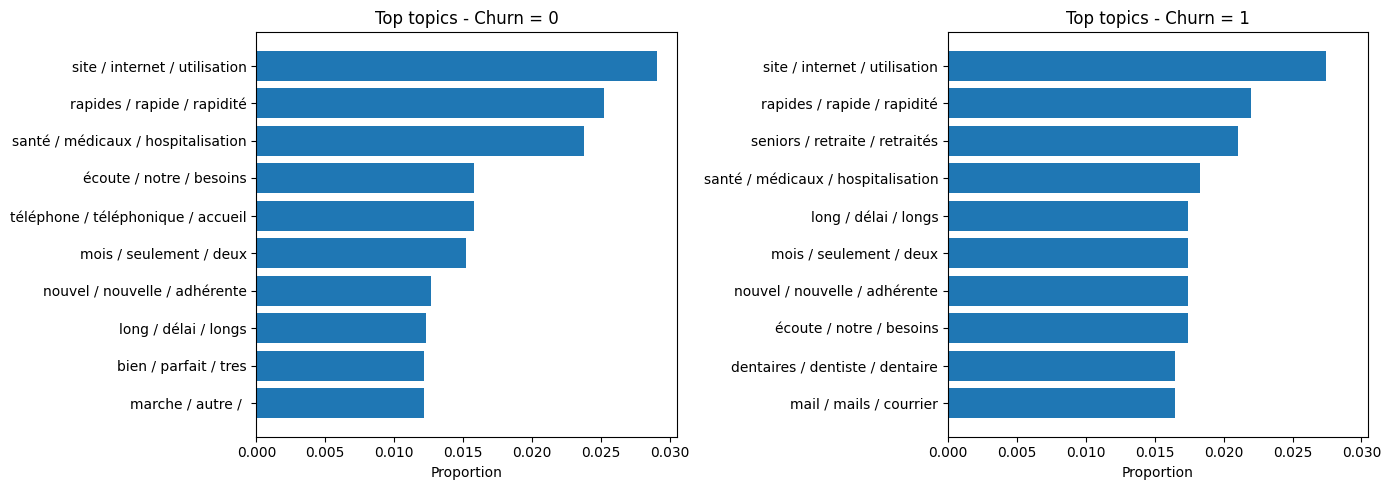

In [32]:
top_topics_by_churn = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["target_resiliation_6mois", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_topics_by_churn["proportion"] = (
    top_topics_by_churn.groupby("target_resiliation_6mois")["count"]
    .transform(lambda x: x / x.sum())
)

top_topics_by_churn = top_topics_by_churn.sort_values(
    ["target_resiliation_6mois", "count"], ascending=[True, False]
)



fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for i, churn_value in enumerate([0, 1]):
    plot_df = (
        top_topics_by_churn[top_topics_by_churn["target_resiliation_6mois"] == churn_value]
        .head(10)
        .sort_values("proportion", ascending=True)
    )

    axes[i].barh(plot_df["topic_label"], plot_df["proportion"])
    axes[i].set_title(f"Top topics - Churn = {churn_value}")
    axes[i].set_xlabel("Proportion")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

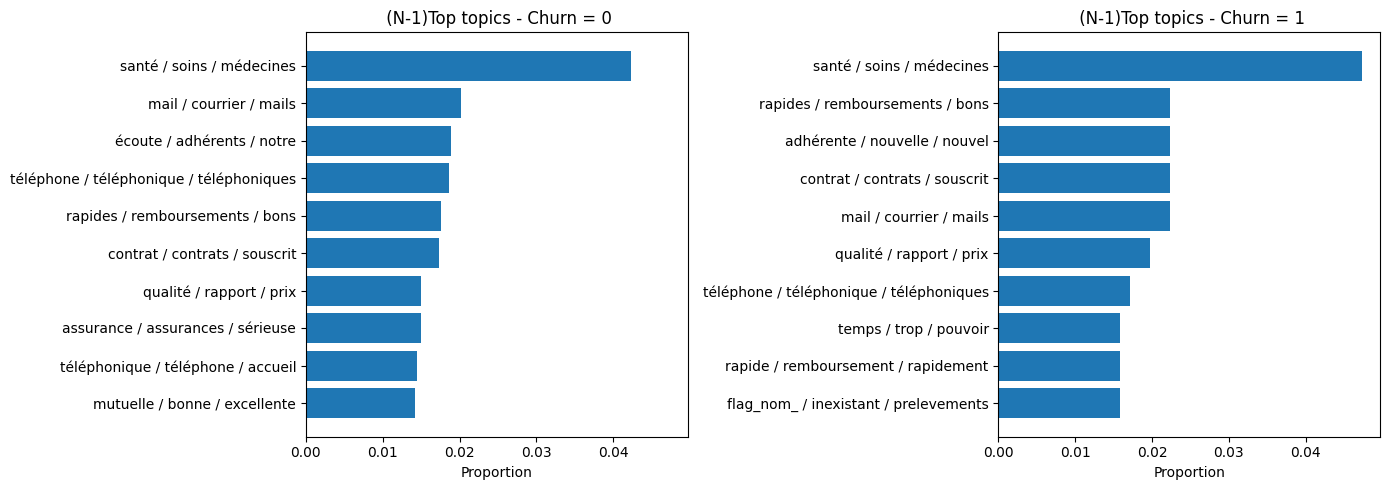

In [33]:
top_topics_by_churn_moins1 = (
    df_topic_moins1[df_topic_moins1["topic"] != -1]
    .groupby(["target_resiliation_6mois", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_topics_by_churn_moins1["proportion"] = (
    top_topics_by_churn_moins1.groupby("target_resiliation_6mois")["count"]
    .transform(lambda x: x / x.sum())
)

top_topics_by_churn_moins1 = top_topics_by_churn_moins1.sort_values(
    ["target_resiliation_6mois", "count"], ascending=[True, False]
)



fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for i, churn_value in enumerate([0, 1]):
    plot_df = (
        top_topics_by_churn_moins1[top_topics_by_churn_moins1["target_resiliation_6mois"] == churn_value]
        .head(10)
        .sort_values("proportion", ascending=True)
    )

    axes[i].barh(plot_df["topic_label"], plot_df["proportion"])
    axes[i].set_title(f" (N-1)Top topics - Churn = {churn_value}")
    axes[i].set_xlabel("Proportion")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [34]:
def nps_group(score):
    if score <= 6:
        return "Détracteurs"
    elif score <= 8:
        return "Passifs"
    else:
        return "Promoteurs"

df_topic["nps_group"] = df_topic["client_nps_note_reco_n"].apply(nps_group)

top_topics_by_nps = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["nps_group", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_topics_by_nps["proportion"] = (
    top_topics_by_nps.groupby("nps_group")["count"]
    .transform(lambda x: x / x.sum())
)

top_topics_by_nps = top_topics_by_nps.sort_values(
    ["nps_group", "count"], ascending=[True, False]
)

top_5_topics_by_nps = (
    top_topics_by_nps.groupby("nps_group")
    .head(5)
    .reset_index(drop=True)
)

print(top_5_topics_by_nps)

      nps_group                         topic_label  count  proportion
0   Détracteurs                long / délai / longs     77    0.052560
1   Détracteurs     dentaires / dentiste / dentaire     57    0.038908
2   Détracteurs             mail / mails / courrier     51    0.034812
3   Détracteurs  santé / médicaux / hospitalisation     50    0.034130
4   Détracteurs             mois / seulement / deux     43    0.029352
5       Passifs         rapides / rapide / rapidité     51    0.024367
6       Passifs  santé / médicaux / hospitalisation     51    0.024367
7       Passifs       site / internet / utilisation     50    0.023889
8       Passifs             mois / seulement / deux     38    0.018156
9       Passifs                   marche / autre /      37    0.017678
10   Promoteurs       site / internet / utilisation    109    0.035785
11   Promoteurs         rapides / rapide / rapidité    105    0.034471
12   Promoteurs            écoute / notre / besoins     75    0.024622
13   P

In [35]:
df_topic_moins1["nps_group"] = df_topic_moins1["client_nps_note_reco_n"].apply(nps_group)

top_topics_by_nps_moins1 = (
    df_topic_moins1[df_topic_moins1["topic"] != -1]
    .groupby(["nps_group", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_topics_by_nps_moins1["proportion"] = (
    top_topics_by_nps_moins1.groupby("nps_group")["count"]
    .transform(lambda x: x / x.sum())
)

top_topics_by_nps_moins1 = top_topics_by_nps_moins1.sort_values(
    ["nps_group", "count"], ascending=[True, False]
)

top_5_topics_by_nps_moins1 = (
    top_topics_by_nps_moins1.groupby("nps_group")
    .head(5)
    .reset_index(drop=True)
)

print(top_5_topics_by_nps_moins1)

      nps_group                               topic_label  count  proportion
0   Détracteurs                   mail / courrier / mails     13    0.042763
1   Détracteurs                  cher / trop / compliquer     11    0.036184
2   Détracteurs           dentaires / dentiste / dentaire     11    0.036184
3   Détracteurs                 santé / soins / médecines     11    0.036184
4   Détracteurs                    temps / trop / pouvoir      9    0.029605
5       Passifs                 santé / soins / médecines     30    0.057803
6       Passifs        téléphonique / téléphone / accueil     11    0.021195
7       Passifs           rapides / remboursements / bons     10    0.019268
8       Passifs                écoute / adhérents / notre     10    0.019268
9       Passifs             adhérente / nouvelle / nouvel      9    0.017341
10   Promoteurs                 santé / soins / médecines    156    0.041711
11   Promoteurs                   mail / courrier / mails     76    0.020321

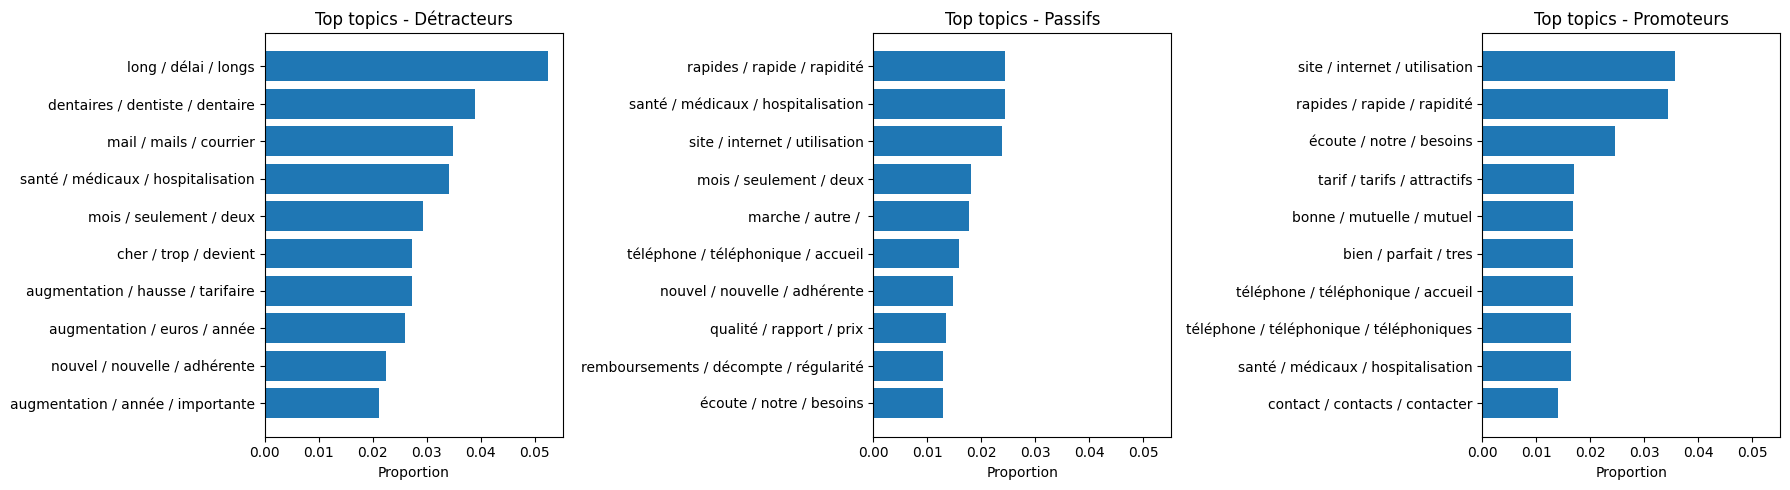

In [36]:
groups = ["Détracteurs", "Passifs", "Promoteurs"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for i, group in enumerate(groups):
    plot_df = (
        top_topics_by_nps[top_topics_by_nps["nps_group"] == group]
        .head(10)
        .sort_values("proportion", ascending=True)
    )

    axes[i].barh(plot_df["topic_label"], plot_df["proportion"])
    axes[i].set_title(f"Top topics - {group}")
    axes[i].set_xlabel("Proportion")

plt.tight_layout()
plt.show()

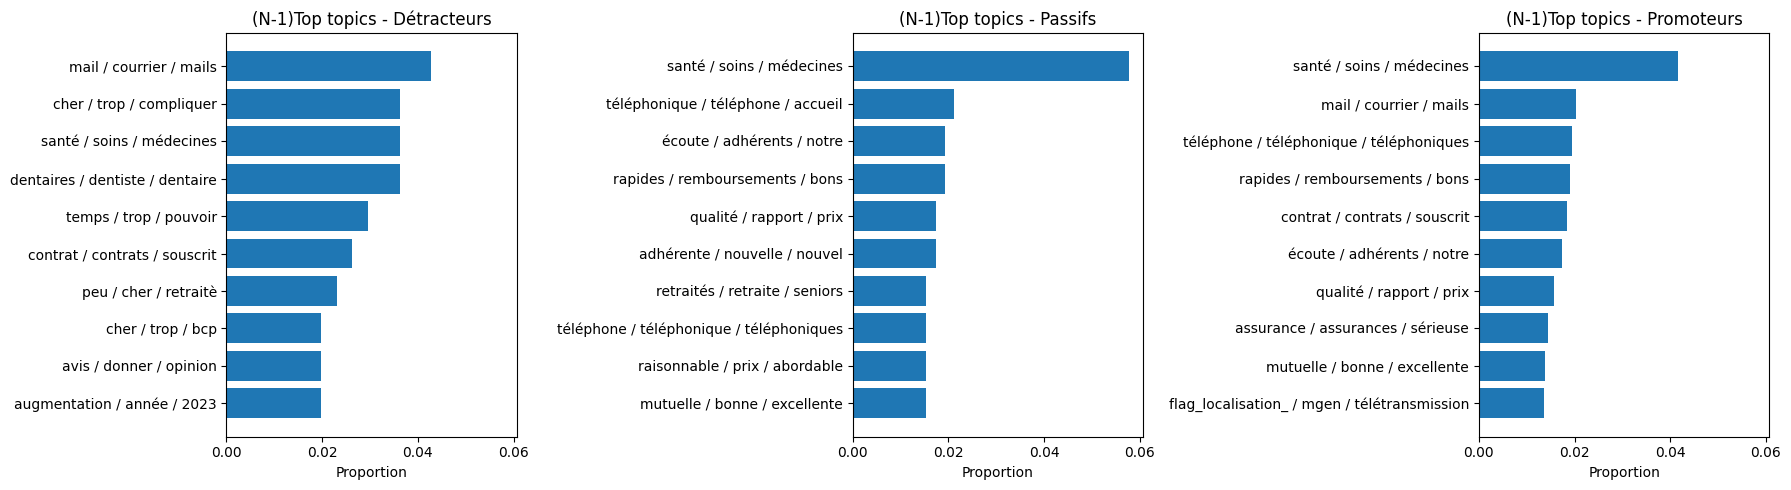

In [37]:
groups = ["Détracteurs", "Passifs", "Promoteurs"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for i, group in enumerate(groups):
    plot_df = (
        top_topics_by_nps_moins1[top_topics_by_nps_moins1["nps_group"] == group]
        .head(10)
        .sort_values("proportion", ascending=True)
    )

    axes[i].barh(plot_df["topic_label"], plot_df["proportion"])
    axes[i].set_title(f"(N-1)Top topics - {group}")
    axes[i].set_xlabel("Proportion")

plt.tight_layout()
plt.show()

In [38]:
df_nps

,Promoteurs (%),Passifs (%),Détracteurs (%),NPS
0,42.17,34.54,23.29,18.89


In [39]:
# Chargement et preprocessing des données de training et de evaluation

##1. Pre-process training data (scaler and encoder are saved during this process)
train_processor = DataProcessor(mode="training")
df_train = train_processor.run()  #fit training set and save arguments (scaler, ordinal map, target_encoding_maps, ...)

##2. Pre-process test data (by using the same scaler/encoder fitted on training dataset)
test_processor = DataProcessor(mode="validation")

#  HERE:  Reuse the same pre-processor fitted on training dataset (so no data-leakage with target-encoding, normalisation...)
test_processor.target_encoding_maps = train_processor.target_encoding_maps
test_processor.ordinal_maps          = train_processor.ordinal_maps
test_processor.encoded_columns       = train_processor.encoded_columns
test_processor.scaler                = train_processor.scaler
test_processor.normalized_columns    = train_processor.normalized_columns

df_test = test_processor.run_transform() #pre-process test data using same args 

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail', 'client_nps_date_reponse_n_moins1_jours', 'client_nps_date_reponse_n_jours']
INFO:src.data_processing.data_processing:Columns that are One-hot encoded: ['client_mode_paiement', 'courtier_reseau_courtage', 'courtier_segmentation_interne', 'courtier_type_commission', 'recla_canal_entrant_principale', 'recla_canal_entrant_secondaire']
INFO:src.data_processing.data_processing:Columns that are Target encoded: ['client_ro_souscripteur', 'client_produit', 'client_garantie_base',